In [17]:
# Install required packages if missing
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check for PyTorch Lightning
try:
    import pytorch_lightning
except ImportError:
    print("Installing pytorch_lightning...")
    install("pytorch_lightning")

# Check for Seaborn
try:
    import seaborn
except ImportError:
    print("Installing seaborn...")
    install("seaborn")

# Check for PyTDC (tdc) - Optional
try:
    import tdc
except ImportError:
    print("PyTDC not found, but it is optional for this notebook.")

# Check for OmegaConf
try:
    import omegaconf
except ImportError:
    print("Installing omegaconf...")
    install("omegaconf")

# Check for RDKit
try:
    import rdkit
except ImportError:
    print("Installing rdkit...")
    install("rdkit")

# Imports
import torch
import torch.nn as nn
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from tqdm import tqdm

# Fix path
sys.path.append(os.getcwd())

# ConPLex imports
from conplex_dti.dataset.datamodules import get_task_dir, DTIDataModule
from conplex_dti.featurizer import get_featurizer
from conplex_dti.model.architectures import SimpleCoembedding, ACTIVATIONS, DISTANCE_METRICS

# --- CUSTOM CLASS DEFINITIONS TO MATCH CHECKPOINTS ---

# 1. Deep MLP (Matches keys: drug_projector.net.0...)
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout, activation):
        super().__init__()
        # Re-building based on exact keys:
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim), # 0
            activation(),                     # 1
            nn.Dropout(dropout),              # 2
            nn.Linear(output_dim, output_dim),# 3
            activation(),                     # 4
            nn.Dropout(dropout),              # 5
            nn.Linear(output_dim, output_dim),# 6
            activation()                      # 7 (implied)
        )

    def forward(self, x):
        return self.net(x)

class DeepCoembedding(nn.Module):
    def __init__(self, drug_shape, target_shape, latent_dimension, num_layers=3, dropout=0.1, latent_activation="ReLU", latent_distance="Cosine", classify=True):
        super().__init__()
        self.do_classify = classify
        act = ACTIVATIONS[latent_activation]
        
        self.drug_projector = MLP(drug_shape, latent_dimension, latent_dimension, num_layers, dropout, act)
        self.target_projector = MLP(target_shape, latent_dimension, latent_dimension, num_layers, dropout, act)

        if self.do_classify:
            self.distance_metric = latent_distance
            self.activator = DISTANCE_METRICS[self.distance_metric]()

    def forward(self, drug, target):
        drug_projection = self.drug_projector(drug)
        target_projection = self.target_projector(target)
        if self.do_classify:
            return self.activator(drug_projection, target_projection).squeeze()
        return torch.einsum("bd,bd->b", drug_projection, target_projection)

# 2. Residual (Matches keys: drug_projector.0, drug_projector.2.alpha...)
class ResidualBlock(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_model)
        self.fc2 = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
        self.alpha = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        out = self.activation(self.fc1(x))
        out = self.dropout(out)
        out = self.fc2(out)
        return x + self.alpha * out

class ResidualCoembedding(nn.Module):
    def __init__(self, drug_shape, target_shape, latent_dimension, num_blocks=2, dropout=0.1, latent_activation="ReLU", latent_distance="Cosine", classify=True):
        super().__init__()
        self.do_classify = classify
        act = ACTIVATIONS[latent_activation]

        # Drug Projector: Linear -> Act -> Block -> Block ...
        drug_layers = [
            nn.Linear(drug_shape, latent_dimension), # 0
            act()                                    # 1
        ]
        for _ in range(num_blocks + 1): 
            drug_layers.append(ResidualBlock(latent_dimension, dropout))
        self.drug_projector = nn.Sequential(*drug_layers)

        # Target Projector
        target_layers = [
            nn.Linear(target_shape, latent_dimension),
            act()
        ]
        for _ in range(num_blocks + 1):
            target_layers.append(ResidualBlock(latent_dimension, dropout))
        self.target_projector = nn.Sequential(*target_layers)

        if self.do_classify:
            self.distance_metric = latent_distance
            self.activator = DISTANCE_METRICS[self.distance_metric]()

    def forward(self, drug, target):
        drug_projection = self.drug_projector(drug)
        target_projection = self.target_projector(target)
        if self.do_classify:
            return self.activator(drug_projection, target_projection).squeeze()
        return torch.einsum("bd,bd->b", drug_projection, target_projection)

# 3. Cross-Attention (FIXED: Removed MLP to match checkpoint)
class CrossAttentionCoembedding(nn.Module):
    def __init__(self, drug_shape, target_shape, latent_dimension, num_heads=4, dropout=0.1, latent_activation="ReLU", latent_distance="Cosine", classify=True):
        super().__init__()
        self.do_classify = classify
        
        # Simple Linear Projectors
        self.drug_projector = nn.Linear(drug_shape, latent_dimension)
        self.target_projector = nn.Linear(target_shape, latent_dimension)
        
        # Attention named 'attn'
        self.attn = nn.MultiheadAttention(latent_dimension, num_heads, dropout=dropout, batch_first=True)
        
        # NO MLP HERE - Checkpoint doesn't have it!

        if self.do_classify:
            self.distance_metric = latent_distance
            self.activator = DISTANCE_METRICS[self.distance_metric]()

    def forward(self, drug, target):
        d_emb = self.drug_projector(drug)
        t_emb = self.target_projector(target)
        
        # Attention: Drug attends to Target
        d_seq = d_emb.unsqueeze(1)
        t_seq = t_emb.unsqueeze(1)
        
        # query=drug, key=target, value=target
        attn_out, _ = self.attn(d_seq, t_seq, t_seq)
        d_attended = attn_out.squeeze(1)
        
        # Use the distance metric on the ATTENDED drug embedding and the target embedding
        if self.do_classify:
            return self.activator(d_attended, t_emb).squeeze()
        
        # For regression (if needed)
        return torch.einsum("bd,bd->b", d_attended, t_emb)

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Plotting Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

PyTDC not found, but it is optional for this notebook.
Using device: mps


In [18]:

print("Loading BIOSNAP test set...")
task_dir = get_task_dir("biosnap", database_root="datasets")
drug_featurizer = get_featurizer("MorganFeaturizer", save_dir=task_dir)
target_featurizer = get_featurizer("ProtBertFeaturizer", save_dir=task_dir)

datamodule = DTIDataModule(
    task_dir,
    drug_featurizer,
    target_featurizer,
    device=device,
    batch_size=32,
    shuffle=False,
    num_workers=0
)
datamodule.prepare_data()
datamodule.setup()
test_loader = datamodule.test_dataloader()
print("Data loaded successfully.")


Loading BIOSNAP test set...


Device set to use mps:0
Drug and target featurizers already exist
ProtBert: 100%|██████████| 2181/2181 [00:00<00:00, 4306.35it/s]
Device set to use cpu
Device set to use cpu


Data loaded successfully.


In [19]:
# Define model paths and their specific hyperparameters
models_config = {
    "Baseline (Simple)": {
        "path": "best_models/biosnap_baseline_pure/biosnap_baseline_pure_best_model.pt",
        "class": SimpleCoembedding,
        "kwargs": {
            "drug_shape": 2048,
            "target_shape": 1024,
            "latent_dimension": 1024
        }
    },
    "Deep MLP": {
        "path": "best_models/biosnap_deep_contrastive/biosnap_deep_contrastive_best_model.pt",
        "class": DeepCoembedding, # Ensure this class is defined in the previous cell!
        "kwargs": {
            "drug_shape": 2048,
            "target_shape": 1024,
            "latent_dimension": 1024,
            "num_layers": 3,
            "dropout": 0.1
        }
    },
    "Residual": {
        "path": "best_models/biosnap_residual_improved_v2/biosnap_residual_improved_v2_best_model.pt",
        "class": ResidualCoembedding,
        "kwargs": {
            "drug_shape": 2048,
            "target_shape": 1024,
            "latent_dimension": 1024,
            "num_blocks": 2
        }
    },
    "Cross-Attention": {
        # CORRECTED PATH HERE:
        "path": "best_models/biosnap_crossattn_contrastive_fixed/biosnap_crossattn_contrastive_fixed_best_model.pt",
        "class": CrossAttentionCoembedding,
        "kwargs": {
            "drug_shape": 2048,
            "target_shape": 1024,
            "latent_dimension": 1024,
            "num_heads": 4, # Assuming 4 heads, if it fails try 8
            "dropout": 0.1
        }
    }
}

In [20]:

def evaluate_model(name, config):
    print(f"Evaluating {name}...")
    model_path = config["path"]
    
    if not os.path.exists(model_path):
        print(f"Error: File not found at {model_path}")
        return None

    # Initialize Model with specific kwargs
    try:
        model = config["class"](**config["kwargs"])
    except Exception as e:
        print(f"Error initializing model {name}: {e}")
        return None
    
    # Load Weights
    try:
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()
    except Exception as e:
        print(f"Error loading weights for {name}: {e}")
        return None

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=name):
            drug, target, label = batch
            drug = drug.to(device)
            target = target.to(device)
            
            # Forward pass
            pred = model(drug, target)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(label.numpy())

    return {
        "preds": np.array(all_preds),
        "labels": np.array(all_labels)
    }

results = {}
for name, config in models_config.items():
    res = evaluate_model(name, config)
    if res:
        results[name] = res


Evaluating Baseline (Simple)...


Baseline (Simple): 100%|██████████| 172/172 [00:00<00:00, 243.95it/s]


Evaluating Deep MLP...


Deep MLP: 100%|██████████| 172/172 [00:00<00:00, 206.45it/s]


Evaluating Residual...


Residual: 100%|██████████| 172/172 [00:01<00:00, 142.32it/s]


Evaluating Cross-Attention...


Cross-Attention: 100%|██████████| 172/172 [00:02<00:00, 75.55it/s] 


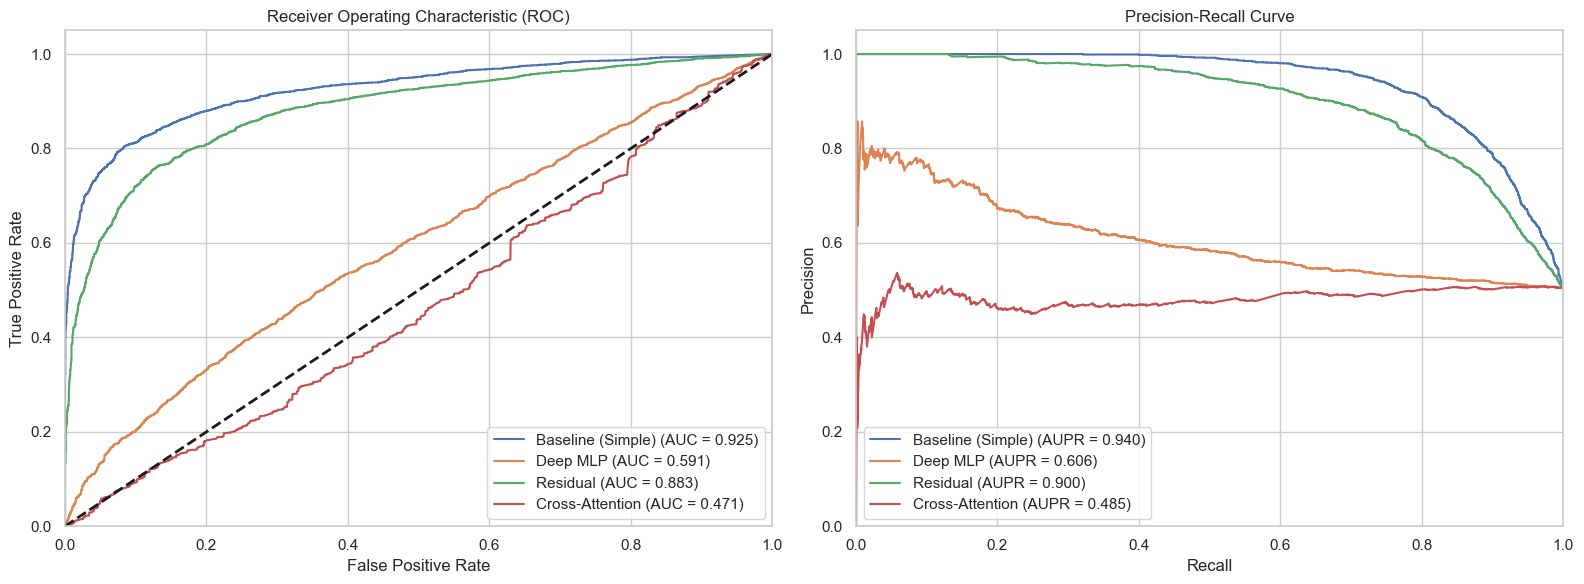

In [21]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(res["labels"], res["preds"])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(res["labels"], res["preds"])
    pr_auc = average_precision_score(res["labels"], res["preds"])
    ax2.plot(recall, precision, label=f'{name} (AUPR = {pr_auc:.3f})')

# ROC Settings
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# PR Settings
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()


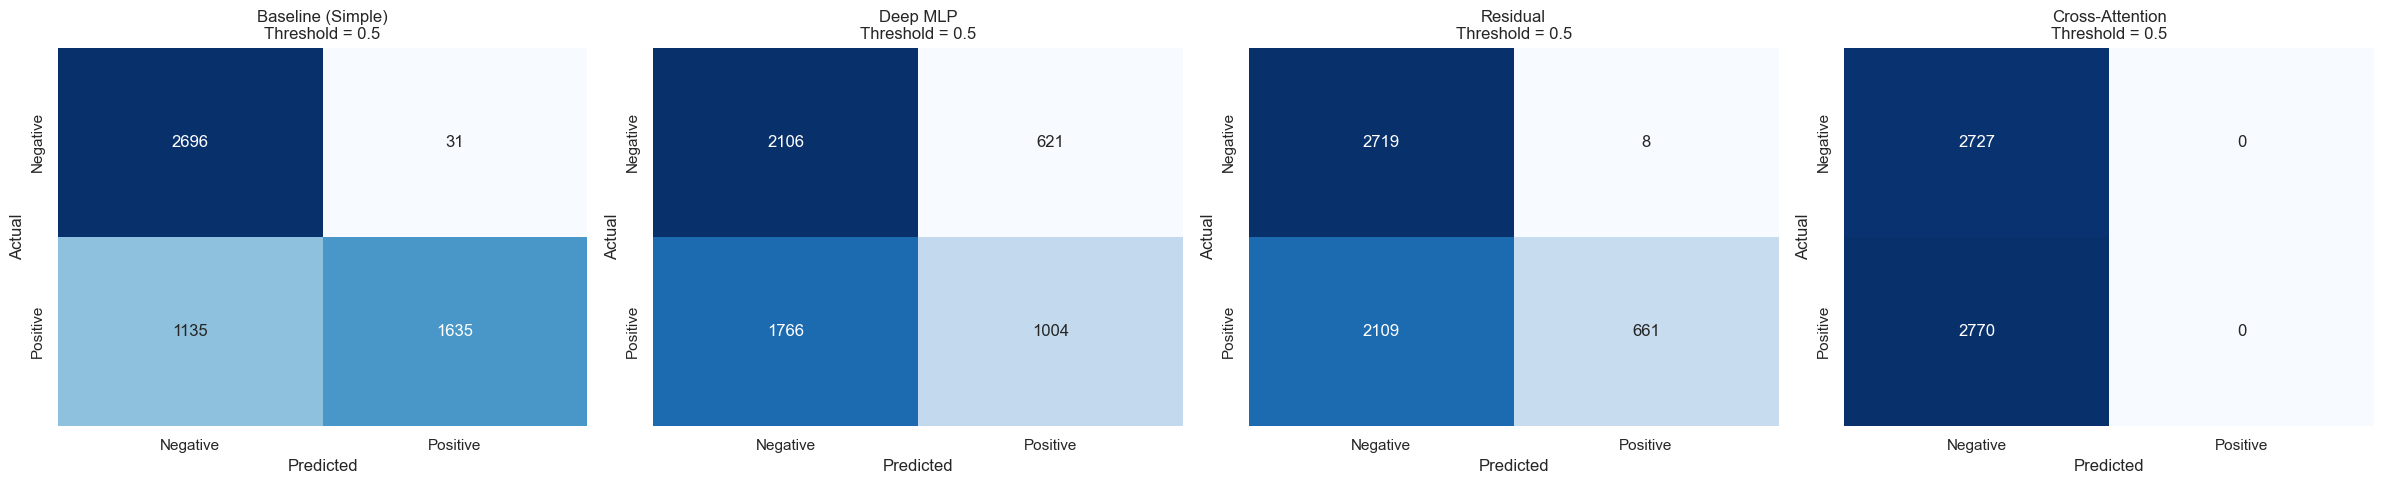

In [22]:

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (name, res) in enumerate(results.items()):
    if i >= 4: break # Limit to 4 plots
    
    # Binarize predictions
    binary_preds = (res["preds"] >= 0.5).astype(int)
    cm = confusion_matrix(res["labels"], binary_preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\nThreshold = 0.5')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Negative', 'Positive'])
    axes[i].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()
